# FIFA World Cup 2026 Forecast

This notebook presents the results of the Monte Carlo simulation for the 2026 FIFA World Cup using the selected prediction model.

The probabilities shown below were estimated from a large number of tournament simulations and represent each team's chances of reaching the knockout stages, advancing through the tournament, and ultimately becoming world champion.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from IPython.display import Markdown, display
from pathlib import Path

from core.constants import WC_2026_RESULT_DIR

In [2]:
run_dir = f"{WC_2026_RESULT_DIR}/1000000-iters__seed-42"

last32_df = pd.read_csv(f"{run_dir}/last_32.csv")
last16_df = pd.read_csv(f"{run_dir}/last_16.csv")
quarter_df = pd.read_csv(f"{run_dir}/quarter.csv")
semi_df = pd.read_csv(f"{run_dir}/semi.csv")
final_df = pd.read_csv(f"{run_dir}/final.csv")
champion_df = pd.read_csv(f"{run_dir}/champion.csv")
top_10_champion_df = champion_df[:10]

In [3]:
match = re.search(r"(\d+)-iters", run_dir)
mc_iters = int(match.group(1))

display(Markdown(f"""
### Simulation Run

- **Monte Carlo iterations:** {mc_iters:,}
"""))


### Simulation Run

- **Monte Carlo iterations:** 1,000,000


## Tournament Progression Summary

The following table summarizes the probability of each team reaching every stage of the tournament.

In [5]:
summary_df = (
    champion_df.rename(columns={"prob": "Champion"})
    .merge(final_df.rename(columns={"prob": "Final"}), on="team")
    .merge(semi_df.rename(columns={"prob": "Semi"}), on="team")
    .merge(quarter_df.rename(columns={"prob": "Quarter"}), on="team")
    .merge(last16_df.rename(columns={"prob": "Round of 16"}), on="team")
    .merge(last32_df.rename(columns={"prob": "Round of 32"}), on="team")
)

summary_df.sort_values("Champion", ascending=False)

,team,Champion,Final,Semi,Quarter,Round of 16,Round of 32
0,spain,0.248176,0.366927,0.508794,0.619284,0.774113,0.982000
1,france,0.196651,0.308971,0.494041,0.635978,0.813181,0.987624
2,england,0.141262,0.256191,0.411421,0.568924,0.770431,0.973021
3,portugal,0.120725,0.229847,0.376010,0.563238,0.742809,0.965560
4,argentina,0.099979,0.207896,0.369956,0.566947,0.704105,0.983121
5,brazil,0.049017,0.108954,0.217844,0.398188,0.618246,0.966574
6,germany,0.024401,0.064662,0.152098,0.273344,0.639281,0.955245
7,netherlands,0.022886,0.065874,0.167396,0.384402,0.553198,0.907923
8,belgium,0.017815,0.058785,0.150486,0.430157,0.714001,0.952005
9,colombia,0.009387,0.034822,0.095792,0.213237,0.442634,0.886756


## Championship Probabilities

Estimated probability of winning the tournament.

In [6]:
top_10_champion_df

,team,prob
0,spain,0.248176
1,france,0.196651
2,england,0.141262
3,portugal,0.120725
4,argentina,0.099979
5,brazil,0.049017
6,germany,0.024401
7,netherlands,0.022886
8,belgium,0.017815
9,colombia,0.009387


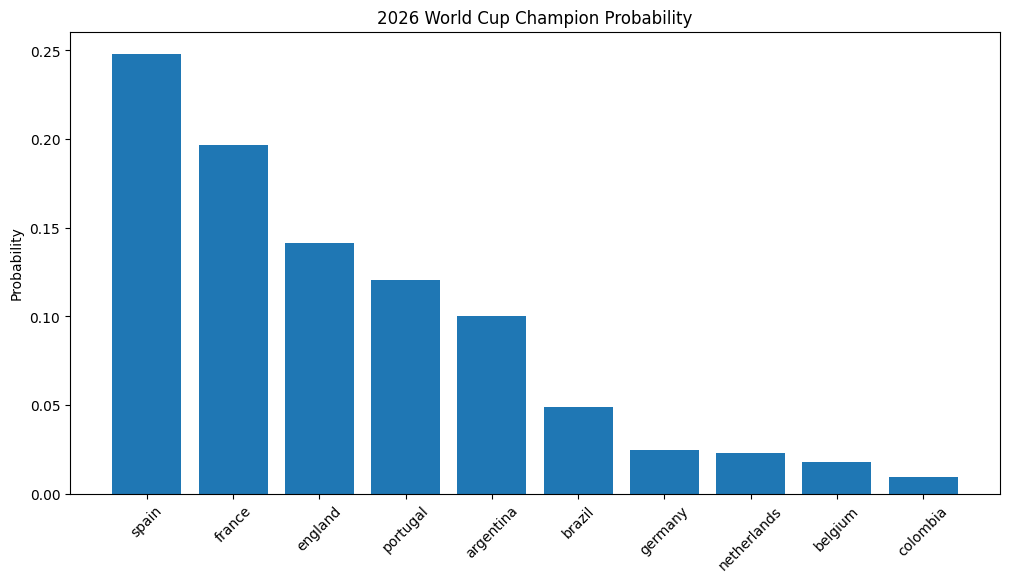

In [7]:
plt.figure(figsize=(12,6))
plt.bar(top_10_champion_df["team"], top_10_champion_df["prob"])
plt.xticks(rotation=45)
plt.ylabel("Probability")
plt.title("2026 World Cup Champion Probability")
plt.show()

## Most Likely Finalists

Teams with the highest probability of reaching the final.

In [8]:
final_df.sort_values("prob", ascending=False).head(20)

,team,prob
0,spain,0.366927
1,france,0.308971
2,england,0.256191
3,portugal,0.229847
4,argentina,0.207896
5,brazil,0.108954
6,netherlands,0.065874
7,germany,0.064662
8,belgium,0.058785
9,colombia,0.034822


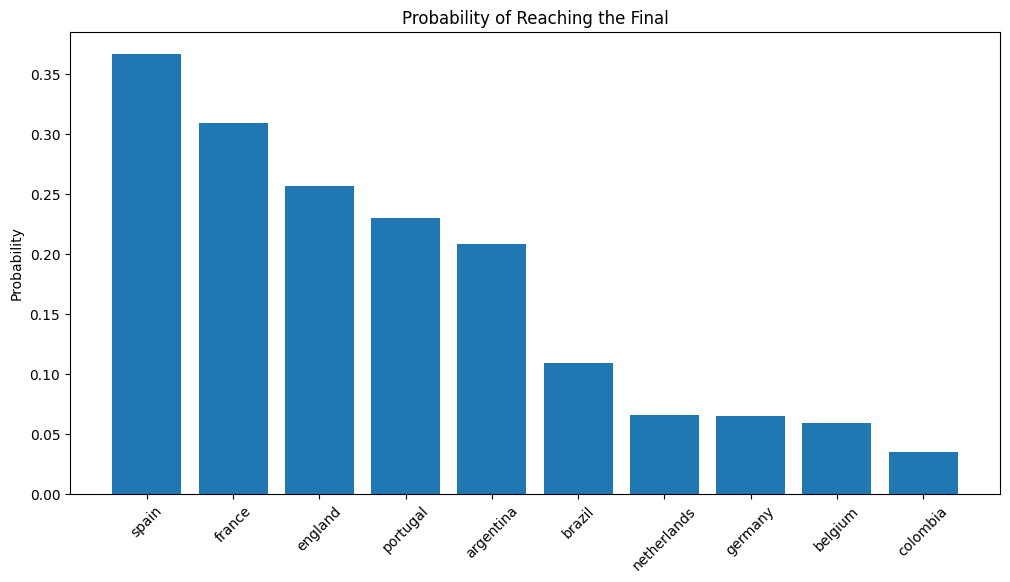

In [9]:
top = final_df.head(10)
plt.figure(figsize=(12,6))
plt.bar(top["team"], top["prob"])
plt.xticks(rotation=45)
plt.ylabel("Probability")
plt.title("Probability of Reaching the Final")
plt.show()

## Semi-final Probabilities

In [10]:
semi_df.head(10)

,team,prob
0,spain,0.508794
1,france,0.494041
2,england,0.411421
3,portugal,0.376010
4,argentina,0.369956
5,brazil,0.217844
6,netherlands,0.167396
7,germany,0.152098
8,belgium,0.150486
9,norway,0.097570


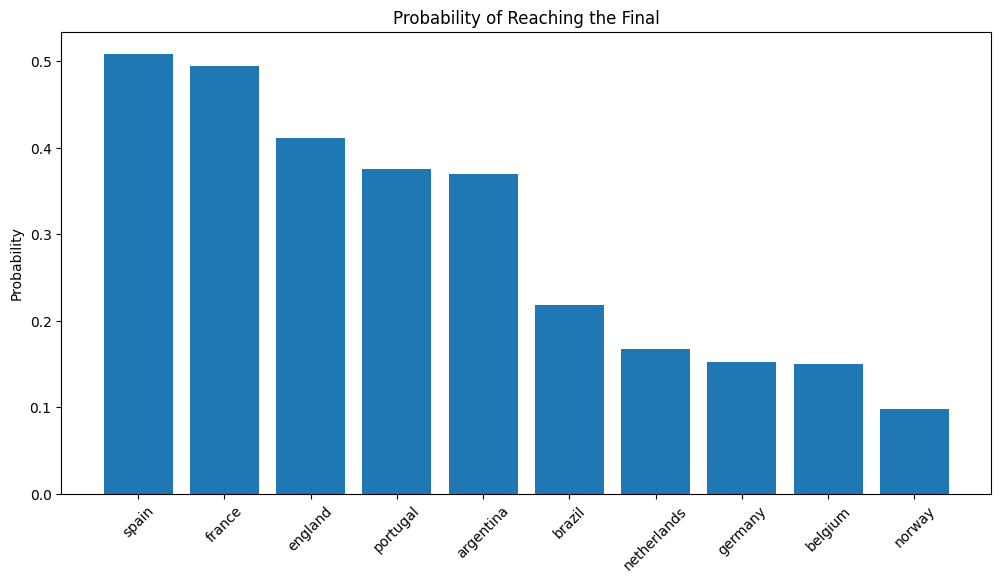

In [11]:
top = semi_df.head(10)
plt.figure(figsize=(12,6))
plt.bar(top["team"], top["prob"])
plt.xticks(rotation=45)
plt.ylabel("Probability")
plt.title("Probability of Reaching the Final")
plt.show()

## Stage Evolution of Top Contenders

Probability progression for the tournament favorites across all stages.

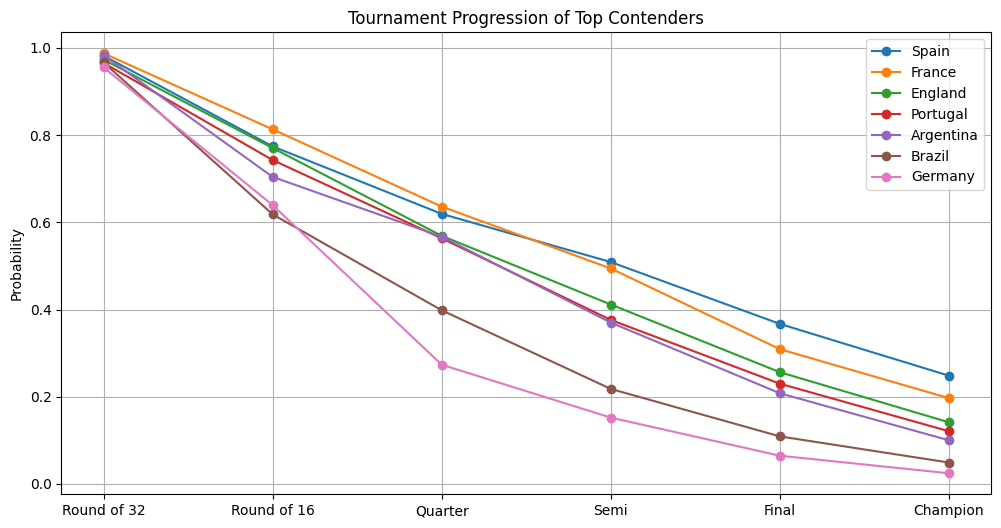

In [12]:
top_teams = (
    summary_df
    .sort_values("Champion", ascending=False)
    .head(7)["team"]
)

stages = [
    "Round of 32",
    "Round of 16",
    "Quarter",
    "Semi",
    "Final",
    "Champion"
]

plt.figure(figsize=(12, 6))

for team in top_teams:
    row = summary_df[summary_df["team"] == team].iloc[0]

    probs = [
        row["Round of 32"],
        row["Round of 16"],
        row["Quarter"],
        row["Semi"],
        row["Final"],
        row["Champion"],
    ]

    plt.plot(
        stages,
        probs,
        marker="o",
        label=team.title()
    )

plt.ylabel("Probability")
plt.title("Tournament Progression of Top Contenders")
plt.legend()
plt.grid(True)
plt.show()